# Modèles et Estimateurs Bayésiens

Dans ce notebook, nous mettons en œuvre des méthodes d'apprentissage bayésien pour modéliser nos cibles.

## Hyperparamètres et Spécificités des Modèles Bayésiens :

### 1. Régression Bayésienne (`BayesianRidge`)
La régression Ridge bayésienne estime un modèle linéaire en introduisant des a priori gaussiens sur les coefficients.
- **`alpha_1` / `alpha_2`** : Hyperparamètres de la loi Gamma a priori sur le paramètre de précision du bruit $\alpha$.
- **`lambda_1` / `lambda_2`** : Hyperparamètres de la loi Gamma a priori sur la précision des poids $\lambda$.
- **`n_iter`** : Nombre maximal d'itérations pour la maximisation de l'évidence.

### 2. Classification Naïve Bayésienne (Naive Bayes)
Repose sur l'application du théorème de Bayes avec l'hypothèse « naïve » d'indépendance conditionnelle entre les caractéristiques.
- **`GaussianNB`** : Supposé pour des caractéristiques continues suivant une distribution gaussienne.
  - **`var_smoothing`** : Portion de la variance maximale ajoutée aux variances pour la stabilité numérique.
- **`MultinomialNB`** : Adapté aux fréquences ou décomptes.
  - **`alpha`** : Paramètre de lissage de Laplace/Lidstone ($alpha=1.0$ par défaut).
- **`BernoulliNB`** : Adapté aux caractéristiques binaires (présence/absence).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_validate

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, REPORT_FAMILIES, THRESHOLDS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, deposit_labels, evaluate, save_results,
)


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)


In [3]:
train = load_train()
print(f"Dataset d'entraînement chargé : {train.shape[0]} lignes, {train['input_group'].nunique()} groupes d'assemblage.")


Dataset d'entraînement chargé : 1332 lignes, 496 groupes d'assemblage.


### 1. Régression Bayésienne (`BayesianRidge`)

Optimisation automatique des hyperparamètres de régularisation via la maximisation de l'évidence (*marginal likelihood*).

In [4]:
param_grid_bayes_ridge = {
    "bayes__alpha_1": [1e-6, 1e-4, 1e-2],
    "bayes__alpha_2": [1e-6, 1e-4, 1e-2],
    "bayes__lambda_1": [1e-6, 1e-4, 1e-2],
    "bayes__lambda_2": [1e-6, 1e-4, 1e-2]
}

best_bayes_ridge_models = {}

for target in TARGETS:
    X, y, cv = get_xy(train, target)
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("bayes", BayesianRidge())
    ])
    
    grid_search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_bayes_ridge,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    grid_search.fit(X, y)
    
    best_model = grid_search.best_estimator_
    best_score = -grid_search.best_score_
    best_bayes_ridge_models[target] = best_model
    
    print(f"Target '{target:20s}' - Meilleure MAE BayesianRidge : {best_score:.3f}")
    print(f"  Params : {grid_search.best_params_}\n")


Target 'yield_strength_MPa  ' - Meilleure MAE BayesianRidge : 51.793
  Params : {'bayes__alpha_1': 0.01, 'bayes__alpha_2': 1e-06, 'bayes__lambda_1': 1e-06, 'bayes__lambda_2': 0.01}

Target 'uts_MPa             ' - Meilleure MAE BayesianRidge : 44.544
  Params : {'bayes__alpha_1': 1e-06, 'bayes__alpha_2': 0.01, 'bayes__lambda_1': 0.01, 'bayes__lambda_2': 1e-06}

Target 'elongation_pct      ' - Meilleure MAE BayesianRidge : 2.791
  Params : {'bayes__alpha_1': 0.01, 'bayes__alpha_2': 1e-06, 'bayes__lambda_1': 1e-06, 'bayes__lambda_2': 0.01}

Target 'charpy_toughness_J  ' - Meilleure MAE BayesianRidge : 30.285
  Params : {'bayes__alpha_1': 0.01, 'bayes__alpha_2': 1e-06, 'bayes__lambda_1': 1e-06, 'bayes__lambda_2': 0.01}



### 2. Alternative Naive Bayes (`GaussianNB`)

Ajustement du paramètre de lissage de la variance (`var_smoothing`) pour traiter d'éventuels problèmes de stabilité numérique ou d'échelles.

In [5]:
class NaiveBayesRegressor(BaseEstimator, RegressorMixin):
    """Gaussian Naive Bayes sur une cible continue discrétisée en quantiles."""
    def __init__(self, n_bins=10, var_smoothing=1e-9):
        self.n_bins = n_bins
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        edges = np.unique(np.quantile(y, np.linspace(0, 1, self.n_bins + 1)))
        labels = np.clip(np.digitize(y, edges[1:-1]), 0, len(edges) - 2)
        self.gnb_ = GaussianNB(var_smoothing=self.var_smoothing).fit(X, labels)
        self.class_means_ = np.array([y[labels == c].mean() for c in self.gnb_.classes_])
        return self

    def predict(self, X):
        return self.gnb_.predict_proba(X) @ self.class_means_

In [6]:
param_grid_nb = {
    "nb__n_bins": [5, 10, 20],
    "nb__var_smoothing": np.logspace(0, -9, num=10),
}

best_nb_models = {}

for target in TARGETS:
    X, y, cv = get_xy(train, target)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("nb", NaiveBayesRegressor())
    ])

    grid_search = GridSearchCV(pipe, param_grid_nb, cv=cv,
                               scoring="neg_mean_absolute_error", n_jobs=-1)
    grid_search.fit(X, y)

    best_nb_models[target] = grid_search.best_estimator_
    print(f"Target '{target:20s}' - Naive Bayes MAE : {-grid_search.best_score_:.3f}")
    print(f"  Params : {grid_search.best_params_}\n")

Target 'yield_strength_MPa  ' - Naive Bayes MAE : 60.473
  Params : {'nb__n_bins': 5, 'nb__var_smoothing': np.float64(1e-05)}

Target 'uts_MPa             ' - Naive Bayes MAE : 49.984
  Params : {'nb__n_bins': 20, 'nb__var_smoothing': np.float64(0.01)}

Target 'elongation_pct      ' - Naive Bayes MAE : 3.203
  Params : {'nb__n_bins': 5, 'nb__var_smoothing': np.float64(0.001)}

Target 'charpy_toughness_J  ' - Naive Bayes MAE : 33.636
  Params : {'nb__n_bins': 20, 'nb__var_smoothing': np.float64(0.1)}



### 3. Visualisation de l'effet du lissage de variance (`var_smoothing`)

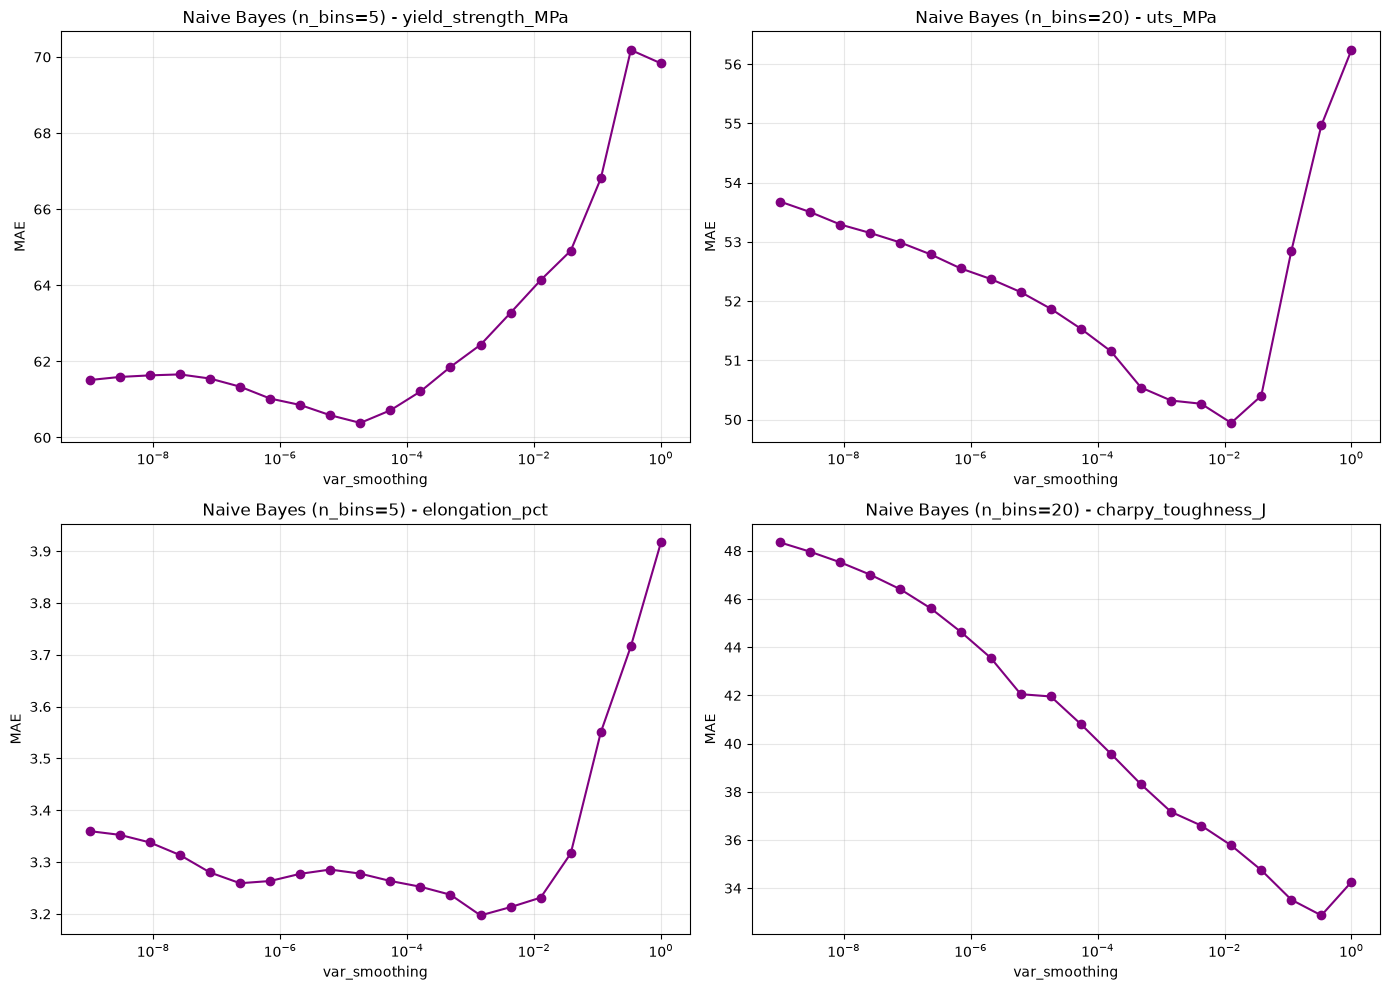

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGETS):
    X, y, cv = get_xy(train, target)
    best_bins = best_nb_models[target].named_steps["nb"].n_bins

    var_smoothings = np.logspace(0, -9, num=20)
    val_scores = []
    for vs in var_smoothings:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("nb", NaiveBayesRegressor(n_bins=best_bins, var_smoothing=vs))
        ])
        res = cross_validate(pipe, X, y, cv=cv, scoring="neg_mean_absolute_error")
        val_scores.append(-res["test_score"].mean())

    ax = axes[idx]
    ax.semilogx(var_smoothings, val_scores, marker="o", color="purple")
    ax.set_title(f"Naive Bayes (n_bins={best_bins}) - {target}")
    ax.set_xlabel("var_smoothing")
    ax.set_ylabel("MAE")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Évaluation finale et enregistrement des résultats

In [8]:
results_bayes_ridge = evaluate("Bayesian Ridge", best_bayes_ridge_models, train)
results_bayes_ridge

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,Bayesian Ridge,yield_strength_MPa,all,620,51.922572,69.763850,5.525918,6.555493,619,102,0.359712,0.245098
1,Bayesian Ridge,yield_strength_MPa,C-Mn,552,47.966202,63.244653,4.701770,3.414841,552,102,0.359712,0.245098
2,Bayesian Ridge,yield_strength_MPa,CrMo2,30,79.513067,114.525204,56.878093,70.638793,29,0,0.000000,0.000000
3,Bayesian Ridge,yield_strength_MPa,CrMo91,38,87.612075,104.644632,31.227671,29.677726,38,0,0.000000,0.000000
4,Bayesian Ridge,uts_MPa,all,596,44.636790,61.999961,5.338061,10.305556,595,198,0.558730,0.444444
5,Bayesian Ridge,uts_MPa,C-Mn,531,42.158437,55.388953,2.687094,1.814595,531,198,0.558730,0.444444
6,Bayesian Ridge,uts_MPa,CrMo2,34,67.492258,115.399588,55.346250,76.890983,33,0,0.000000,0.000000
7,Bayesian Ridge,uts_MPa,CrMo91,31,62.021287,82.142061,16.817325,29.124425,31,0,0.000000,0.000000
8,Bayesian Ridge,elongation_pct,all,558,2.792303,3.618330,0.225441,0.445108,557,48,0.285714,0.208333
9,Bayesian Ridge,elongation_pct,C-Mn,497,2.733913,3.467595,0.172479,0.225357,497,37,0.139535,0.081081


In [9]:
results_bayes_naive = evaluate("Naive bayesian", best_nb_models, train)
results_bayes_naive

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,Naive bayesian,yield_strength_MPa,all,620,60.617430,82.674068,5.403636,7.554521,619,102,0.533333,0.745098
1,Naive bayesian,yield_strength_MPa,C-Mn,552,58.570130,77.556919,3.244920,2.829492,552,102,0.533333,0.745098
2,Naive bayesian,yield_strength_MPa,CrMo2,30,50.200042,65.889068,23.011467,27.379124,29,0,0.000000,0.000000
3,Naive bayesian,yield_strength_MPa,CrMo91,38,98.581399,143.924154,62.225017,65.818072,38,0,0.000000,0.000000
4,Naive bayesian,uts_MPa,all,596,50.132764,69.173716,6.349259,7.253094,595,198,0.496970,0.414141
5,Naive bayesian,uts_MPa,C-Mn,531,50.031910,68.298314,4.780148,4.403111,531,198,0.496970,0.414141
6,Naive bayesian,uts_MPa,CrMo2,34,52.055668,71.209460,29.080908,35.703243,33,0,0.000000,0.000000
7,Naive bayesian,uts_MPa,CrMo91,31,49.751322,80.826516,34.185637,45.315355,31,0,0.000000,0.000000
8,Naive bayesian,elongation_pct,all,558,3.206453,4.094173,0.274447,0.270742,557,48,0.071429,0.041667
9,Naive bayesian,elongation_pct,C-Mn,497,3.217720,4.117925,0.275443,0.298260,497,37,0.088889,0.054054


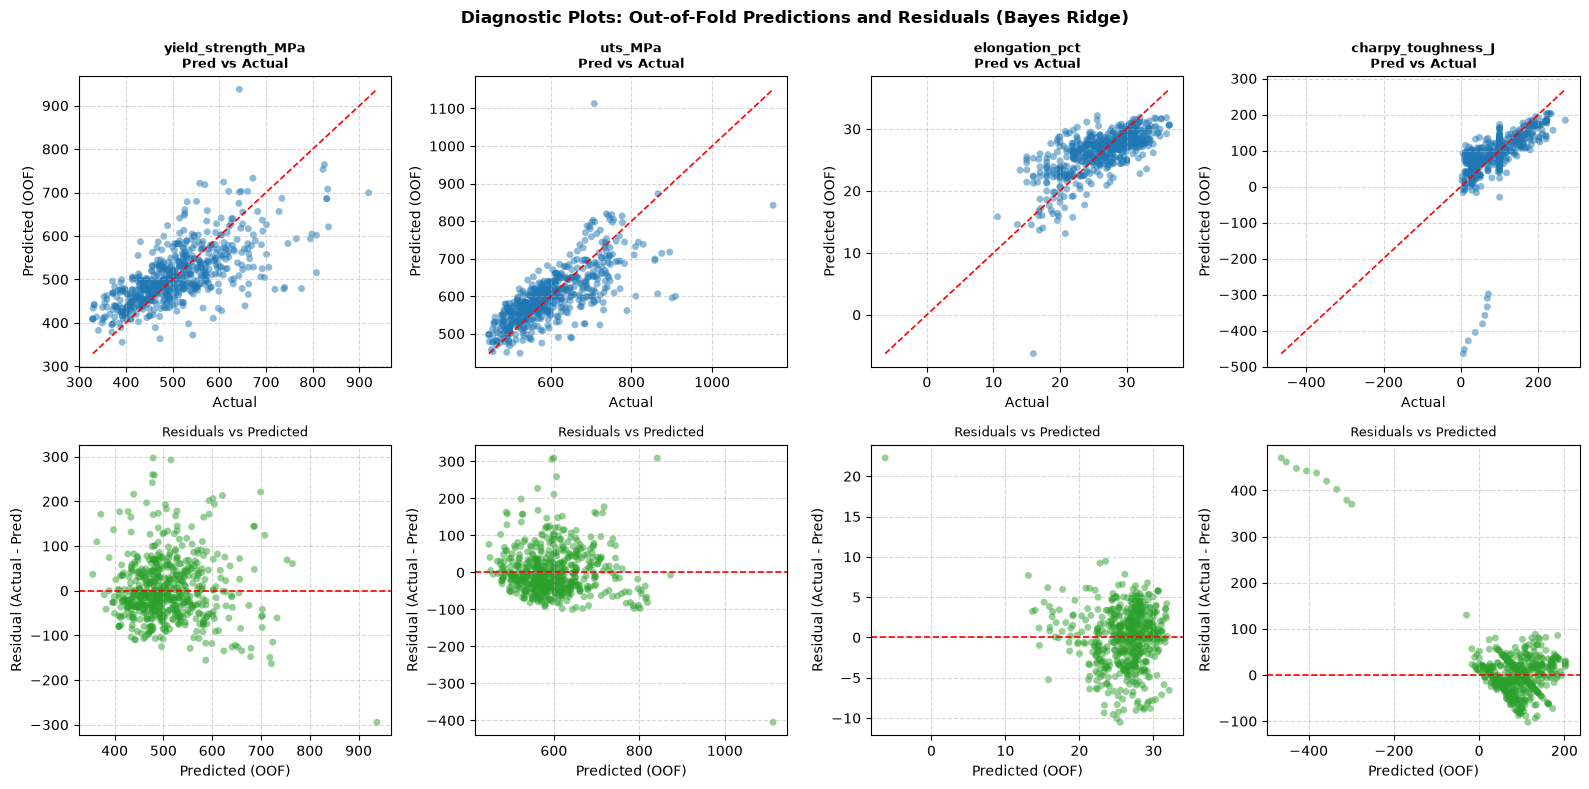

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, target in enumerate(TARGETS):
    X, y, _ = get_xy(train, target)
    oof_fwd = oof_predict(best_bayes_ridge_models[target], train, target)
    y_val = y.loc[oof_fwd.index]
    pred = oof_fwd["pred"]
    resids = y_val - pred
    
    ax_sc = axes[0, i]
    ax_sc.scatter(y_val, pred, alpha=0.5, edgecolors="none", s=25, color="#1f77b4")
    min_v, max_v = min(y_val.min(), pred.min()), max(y_val.max(), pred.max())
    ax_sc.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.2)
    ax_sc.set_title(f"{target}\nPred vs Actual", fontsize=9, fontweight="bold")
    ax_sc.set_xlabel("Actual")
    ax_sc.set_ylabel("Predicted (OOF)")
    ax_sc.grid(True, linestyle="--", alpha=0.5)
    
    ax_res = axes[1, i]
    ax_res.scatter(pred, resids, alpha=0.5, edgecolors="none", s=25, color="#2ca02c")
    ax_res.axhline(0, color="r", linestyle="--", linewidth=1.2)
    ax_res.set_title("Residuals vs Predicted", fontsize=9)
    ax_res.set_xlabel("Predicted (OOF)")
    ax_res.set_ylabel("Residual (Actual - Pred)")
    ax_res.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Diagnostic Plots: Out-of-Fold Predictions and Residuals (Bayes Ridge)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


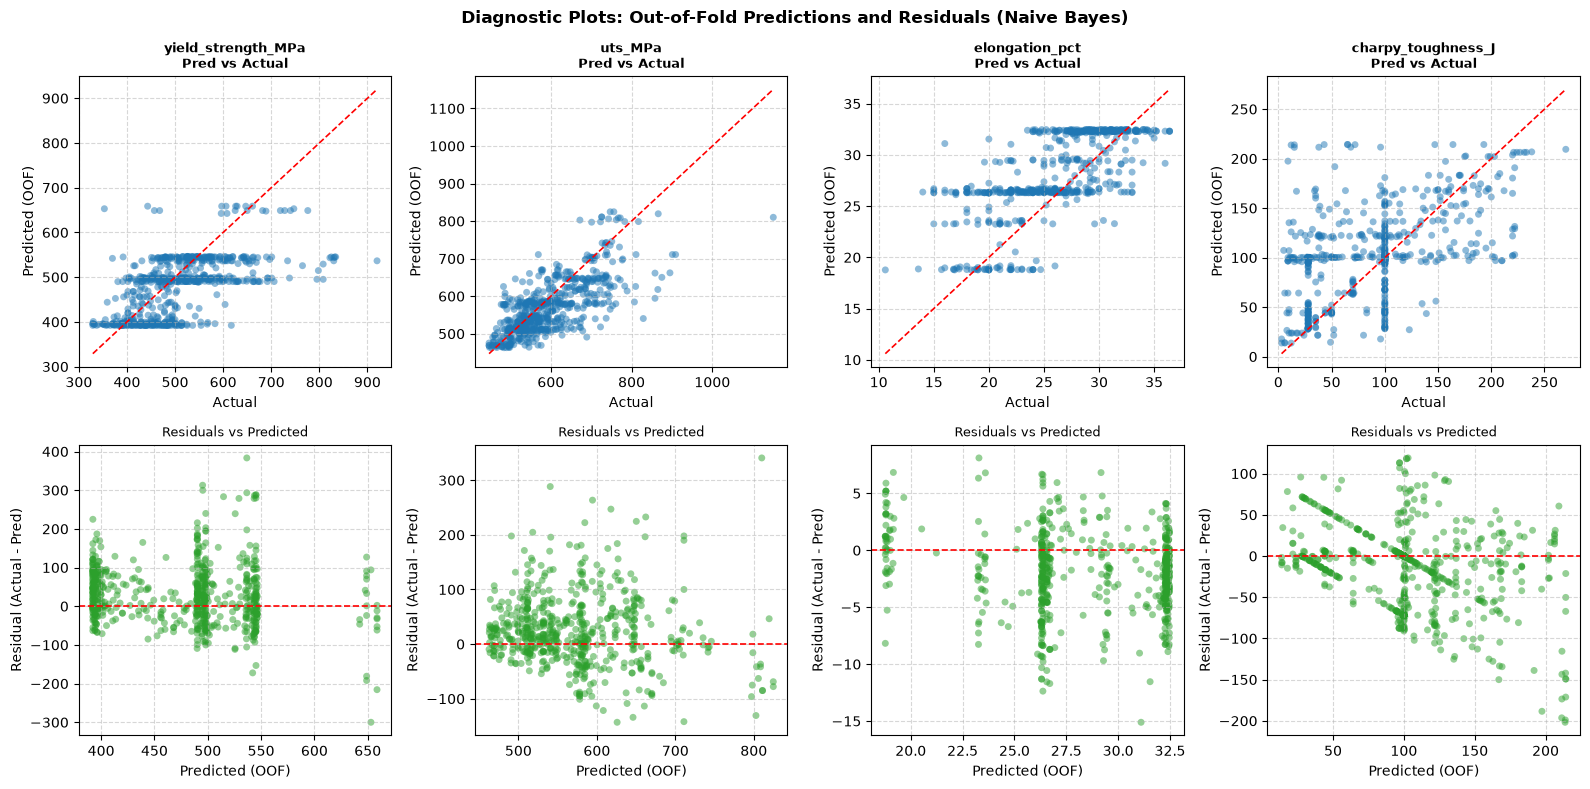

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, target in enumerate(TARGETS):
    X, y, _ = get_xy(train, target)
    oof_fwd = oof_predict(best_nb_models[target], train, target)
    y_val = y.loc[oof_fwd.index]
    pred = oof_fwd["pred"]
    resids = y_val - pred
    
    ax_sc = axes[0, i]
    ax_sc.scatter(y_val, pred, alpha=0.5, edgecolors="none", s=25, color="#1f77b4")
    min_v, max_v = min(y_val.min(), pred.min()), max(y_val.max(), pred.max())
    ax_sc.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.2)
    ax_sc.set_title(f"{target}\nPred vs Actual", fontsize=9, fontweight="bold")
    ax_sc.set_xlabel("Actual")
    ax_sc.set_ylabel("Predicted (OOF)")
    ax_sc.grid(True, linestyle="--", alpha=0.5)
    
    ax_res = axes[1, i]
    ax_res.scatter(pred, resids, alpha=0.5, edgecolors="none", s=25, color="#2ca02c")
    ax_res.axhline(0, color="r", linestyle="--", linewidth=1.2)
    ax_res.set_title("Residuals vs Predicted", fontsize=9)
    ax_res.set_xlabel("Predicted (OOF)")
    ax_res.set_ylabel("Residual (Actual - Pred)")
    ax_res.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Diagnostic Plots: Out-of-Fold Predictions and Residuals (Naive Bayes)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [12]:
# Enregistrement des résultats comparatifs
save_results(results_bayes_naive)
results = save_results(results_bayes_ridge)
models_to_compare = [
    "Baseline (mean)",
    "Linear regression",
    "Linear regression (forward)",
    "Linear regression (backward)",
    "PCR",
    "Pruned CART",
    "Bagging",
    "Random forest",
    "Extra-Trees",
    "kNN regression",
    "Naive bayesian",
    "Bayesian Ridge"
]
compared = results[results["model"].isin(models_to_compare) & (results["family"] == "all")].set_index(["model", "target"])

print("--- Regression Metrics (MAE & RMSE) ---")
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS, level="target").round(2))

print("\n--- Classification Metrics (F1_nc & recall_nc) ---")
display(compared[["F1_nc", "recall_nc"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS + ["label"], level="target").round(2))

--- Regression Metrics (MAE & RMSE) ---


MAE                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                           72.57   73.45           4.01   
Linear regression                         52.02   45.13           2.79   
Linear regression (forward)               50.26   42.43           2.72   
Linear regression (backward)              50.30   42.26           2.69   
PCR                                       51.84   44.55           2.78   
Pruned CART                               48.24   41.78           2.60   
Bagging                                   35.24   30.86           1.95   
Random forest                             33.95   29.55           1.94   
Extra-Trees                               29.08   25.24           1.78   
kNN regression                            39.48   34.02           2.16   
Naive bayesian                            60.62   50.13           3.21   
Bayesian Ridge                            51.92   44.64           2.79   

                                                              RMSE          \
target                       charpy_toughness_J yield_strength_MPa uts_MPa   
model                                                                        
Baseline (mean)                           39.89              94.41   92.19   
Linear regression                         30.36              69.67   63.01   
Linear regression (forward)               25.14              67.34   59.00   
Linear regression (backward)              25.29              67.36   58.88   
PCR                                       30.36              69.50   62.74   
Pruned CART                               18.87              66.22   59.97   
Bagging                                   19.11              49.40   44.45   
Random forest                             19.09              47.46   42.30   
Extra-Trees                               17.37              42.49   38.84   
kNN regression                            18.04              58.49   52.05   
Naive bayesian                            33.68              82.67   69.17   
Bayesian Ridge                            30.33              69.76   62.00   

                                                                
target                       elongation_pct charpy_toughness_J  
model                                                           
Baseline (mean)                        4.85              51.73  
Linear regression                      3.60              58.54  
Linear regression (forward)            3.50              32.11  
Linear regression (backward)           3.47              31.99  
PCR                                    3.57              58.54  
Pruned CART                            3.32              32.46  
Bagging                                2.51              28.16  
Random forest                          2.51              28.39  
Extra-Trees                            2.36              27.71  
kNN regression                         2.93              34.11  
Naive bayesian                         4.09              50.11  
Bayesian Ridge                         3.62              57.32


--- Classification Metrics (F1_nc & recall_nc) ---


F1_nc                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                            0.00    0.00           0.00   
Linear regression                          0.45    0.57           0.31   
Linear regression (forward)                0.35    0.60           0.30   
Linear regression (backward)               0.40    0.60           0.30   
PCR                                        0.43    0.60           0.29   
Pruned CART                                0.60    0.64           0.46   
Bagging                                    0.68    0.67           0.62   
Random forest                              0.63    0.68           0.59   
Extra-Trees                                0.78    0.74           0.72   
kNN regression                             0.70    0.66           0.58   
Naive bayesian                             0.53    0.50           0.07   
Bayesian Ridge                             0.36    0.56           0.29   

                                                               recall_nc  \
target                       charpy_toughness_J label yield_strength_MPa   
model                                                                      
Baseline (mean)                            0.00  0.00               0.00   
Linear regression                          0.65  0.52               0.33   
Linear regression (forward)                0.67  0.58               0.25   
Linear regression (backward)               0.75  0.59               0.28   
PCR                                        0.65  0.53               0.31   
Pruned CART                                0.52  0.77               0.60   
Bagging                                    0.17  0.81               0.57   
Random forest                              0.26  0.76               0.48   
Extra-Trees                                0.27  0.84               0.65   
kNN regression                             0.78  0.78               0.69   
Naive bayesian                             0.36  0.64               0.75   
Bayesian Ridge                             0.65  0.52               0.25   

                                                                              
target                       uts_MPa elongation_pct charpy_toughness_J label  
model                                                                         
Baseline (mean)                 0.00           0.00               0.00  0.00  
Linear regression               0.47           0.23               0.55  0.39  
Linear regression (forward)     0.49           0.23               0.52  0.43  
Linear regression (backward)    0.49           0.23               0.62  0.45  
PCR                             0.49           0.21               0.55  0.40  
Pruned CART                     0.63           0.50               0.62  0.81  
Bagging                         0.56           0.50               0.10  0.72  
Random forest                   0.54           0.44               0.17  0.64  
Extra-Trees                     0.61           0.60               0.17  0.72  
kNN regression                  0.63           0.48               0.86  0.77  
Naive bayesian                  0.41           0.04               0.38  0.71  
Bayesian Ridge                  0.44           0.21               0.55  0.37